In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)
os.makedirs("tables", exist_ok=True)
plt.rcParams["figure.dpi"] = 140

In [2]:
df = pd.read_csv('diabetes.csv')
features = [c for c in df.columns if c != 'Outcome']

print('Размерность исходной таблицы:', df.shape)
print('Признаки (без Outcome):', features)
display(df.head())

Размерность исходной таблицы: (768, 9)
Признаки (без Outcome): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
medians = df[features].median(numeric_only=True)
Xbin = pd.DataFrame({c: (df[c] <= medians[c]) for c in features})

print('Медианы признаков:')
display(medians)

print('Пример бинаризованной таблицы (True означает <= медианы):')
display(Xbin.head())

Медианы признаков:


Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
dtype: float64

Пример бинаризованной таблицы (True означает <= медианы):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,False,False,True,False,True,False,False,False
1,True,True,True,False,True,True,True,False
2,False,False,True,True,True,True,False,False
3,True,True,True,True,False,True,True,True
4,True,False,True,False,False,False,False,False


Матрица K_ij:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.8113,1.1072,1.1456,0.9760,0.8066,1.0417,0.9764,1.5094
Glucose,1.1072,1.9642,1.1626,1.0781,1.0639,1.1704,1.0588,1.2003
BloodPressure,1.1456,1.1626,1.8329,1.0795,0.9547,1.1729,0.9976,1.2312
SkinThickness,0.9760,1.0781,1.0795,1.9248,1.3734,1.3962,1.1078,1.0013
Insulin,0.8066,1.0639,0.9547,1.3734,2.0000,1.1088,1.1823,0.8232
BMI,1.0417,1.1704,1.1729,1.3962,1.1088,1.9896,1.0725,1.0752
DiabetesPedigreeFunction,0.9764,1.0588,0.9976,1.1078,1.1823,1.0725,2.0000,1.0253
Age,1.5094,1.2003,1.2312,1.0013,0.8232,1.0752,1.0253,1.9394


Saved: colligation_matrix_median.csv


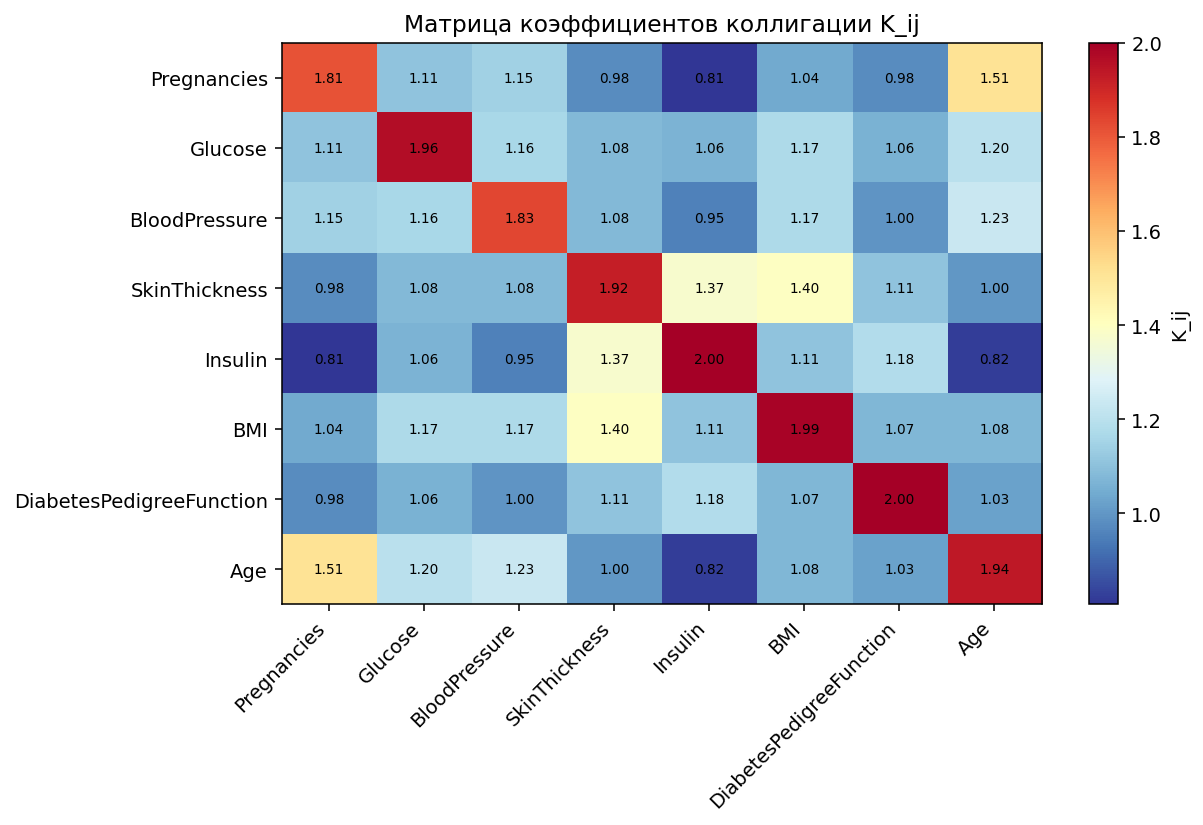

In [4]:
def contingency_2x2(a_event: pd.Series, b_event: pd.Series) -> tuple[int, int, int, int]:
    a_event = a_event.astype(bool)
    b_event = b_event.astype(bool)
    a = int((a_event & b_event).sum())
    b = int((a_event & ~b_event).sum())
    c = int((~a_event & b_event).sum())
    d = int((~a_event & ~b_event).sum())
    return a, b, c, d


def colligation_k(a: int, b: int, c: int, d: int) -> float:
    # K = P(A|B)/P(A)
    n = a + b + c + d
    p_a = (a + b) / n if n else 0.0
    p_a_given_b = a / (a + c) if (a + c) else 0.0
    return (p_a_given_b / p_a) if p_a else 0.0


K = pd.DataFrame(index=features, columns=features, dtype=float)
for i in features:
    for j in features:
        a, b, c, d = contingency_2x2(Xbin[i], Xbin[j])
        K.loc[i, j] = colligation_k(a, b, c, d)

K_rounded = K.round(4)
print('Матрица K_ij:')
display(K_rounded)

# Сохранение
K.to_csv('colligation_matrix_median.csv')
print('Saved: colligation_matrix_median.csv')

# Heatmap для отчёта
plt.figure(figsize=(9, 6))
plt.imshow(K.values.astype(float), cmap='RdYlBu_r', aspect='auto')
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks(range(len(features)), features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{K.iloc[i,j]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(label='K_ij')
plt.title('Матрица коэффициентов коллигации K_ij')
plt.tight_layout()
plt.savefig('images/colligation_K_heatmap.png', bbox_inches='tight')
plt.show()

phi: off-diag min=-0.2147, max=0.5835, mean|.|=0.1476
Yule Q: off-diag min=-0.4127, max=0.8733, mean|.|=0.2717
Yule Y: off-diag min=-0.2160, max=0.5872, mean|.|=0.1480


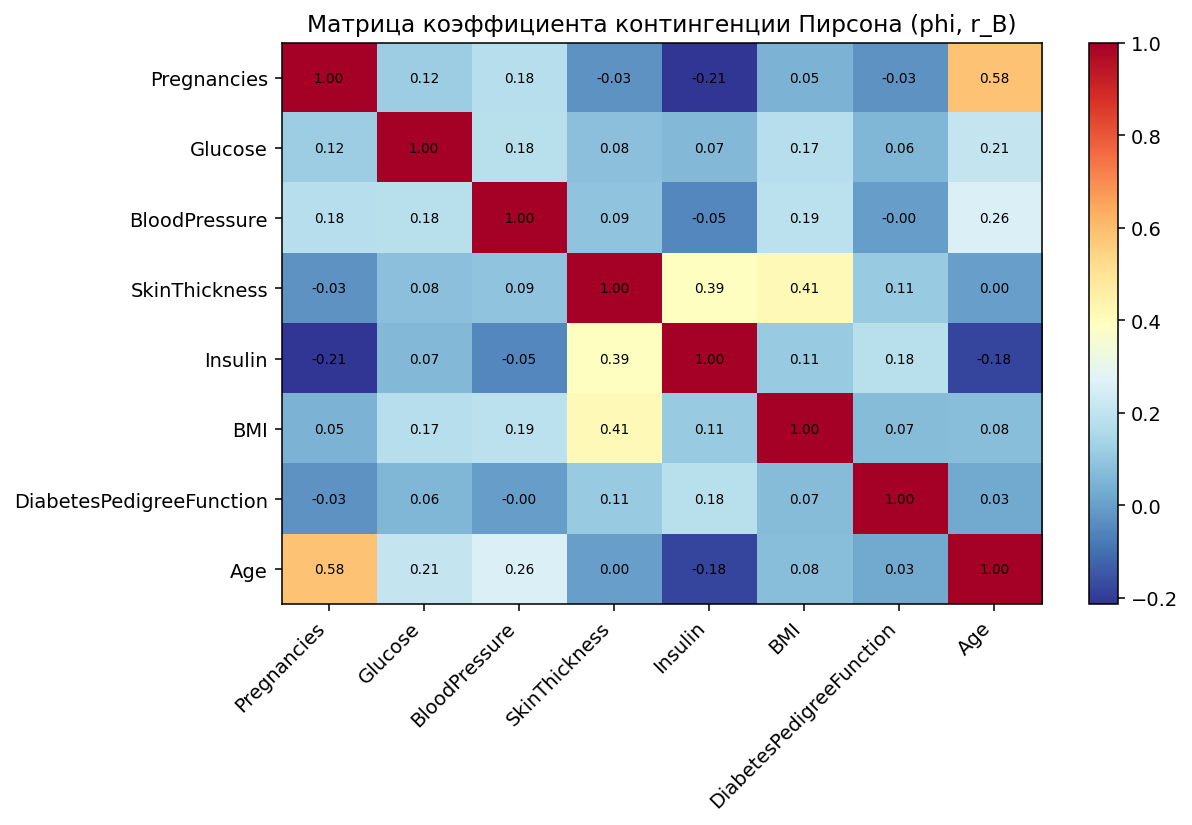

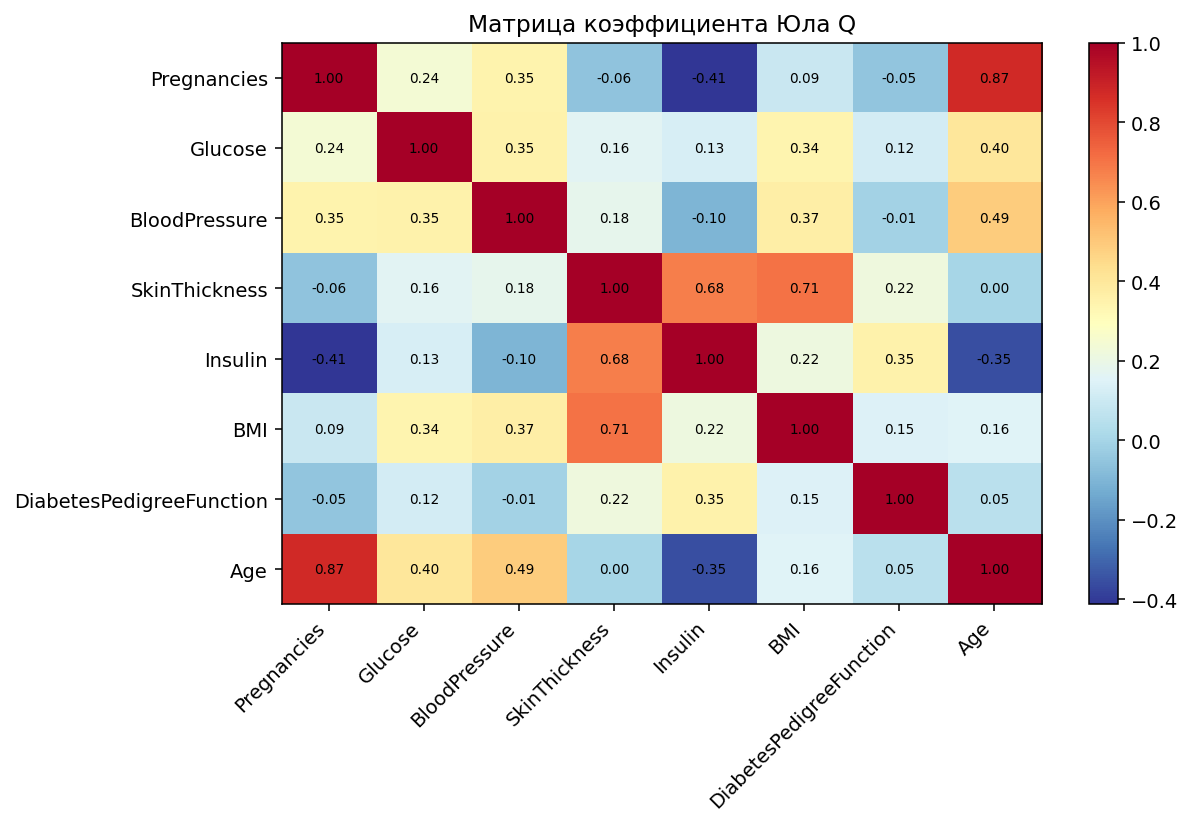

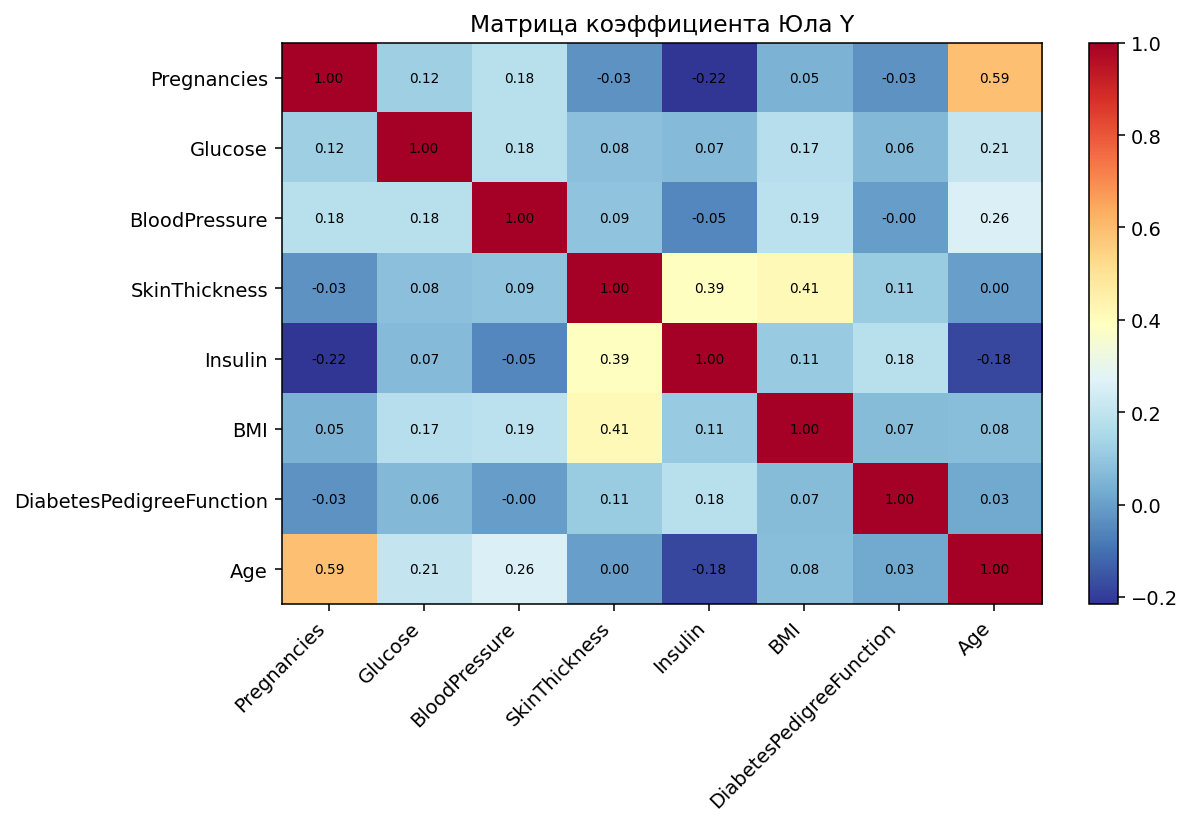

In [5]:
def phi_coef(a: int, b: int, c: int, d: int) -> float:
    denom = (a + b) * (c + d) * (a + c) * (b + d)
    return (a * d - b * c) / np.sqrt(denom) if denom else 0.0


def yule_q(a: int, b: int, c: int, d: int) -> float:
    denom = a * d + b * c
    return (a * d - b * c) / denom if denom else 0.0


def yule_y(a: int, b: int, c: int, d: int) -> float:
    ad = a * d
    bc = b * c
    denom = np.sqrt(ad) + np.sqrt(bc)
    return (np.sqrt(ad) - np.sqrt(bc)) / denom if denom else 0.0


PHI = pd.DataFrame(index=features, columns=features, dtype=float)
Q = pd.DataFrame(index=features, columns=features, dtype=float)
Y = pd.DataFrame(index=features, columns=features, dtype=float)

for i in features:
    for j in features:
        a, b, c, d = contingency_2x2(Xbin[i], Xbin[j])
        PHI.loc[i, j] = phi_coef(a, b, c, d)
        Q.loc[i, j] = yule_q(a, b, c, d)
        Y.loc[i, j] = yule_y(a, b, c, d)


def matrix_summary(M: pd.DataFrame) -> tuple[float, float, float]:
    X = M.to_numpy(dtype=float)
    n = X.shape[0]
    off = X[~np.eye(n, dtype=bool)]
    return float(np.nanmin(off)), float(np.nanmax(off)), float(np.nanmean(np.abs(off)))

mn, mx, mean_abs = matrix_summary(PHI)
print(f'phi: off-diag min={mn:.4f}, max={mx:.4f}, mean|.|={mean_abs:.4f}')
mn, mx, mean_abs = matrix_summary(Q)
print(f'Yule Q: off-diag min={mn:.4f}, max={mx:.4f}, mean|.|={mean_abs:.4f}')
mn, mx, mean_abs = matrix_summary(Y)
print(f'Yule Y: off-diag min={mn:.4f}, max={mx:.4f}, mean|.|={mean_abs:.4f}')

def save_heatmap(mat: pd.DataFrame, title: str, fname: str, cmap: str = 'RdYlBu_r') -> None:
    plt.figure(figsize=(9, 6))
    X = mat.to_numpy(dtype=float)
    plt.imshow(X, cmap=cmap, aspect='auto')
    plt.xticks(range(len(features)), features, rotation=45, ha='right')
    plt.yticks(range(len(features)), features)
    for i in range(len(features)):
        for j in range(len(features)):
            plt.text(j, i, f"{X[i, j]:.2f}", ha='center', va='center', fontsize=7)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

save_heatmap(PHI, 'Матрица коэффициента контингенции Пирсона (phi, r_B)', 'images/phi_heatmap.png')
save_heatmap(Q, 'Матрица коэффициента Юла Q', 'images/yule_Q_heatmap.png')
save_heatmap(Y, 'Матрица коэффициента Юла Y', 'images/yule_Y_heatmap.png')

Лучшие варианты (top-10) по score:


,measure,thr,m,balance,silhouette,davies_bouldin,calinski_harabasz,score,f1_macro,balanced_accuracy
0,abs_Q,0.352858,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
1,abs_Q,0.368999,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
2,abs_Q,0.353192,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
3,abs_phi,0.190425,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
4,abs_phi,0.182381,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
5,abs_phi,0.182292,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
6,abs_Y,0.182476,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
7,abs_Y,0.191248,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
8,abs_Y,0.210603,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104
9,abs_Q,0.403318,2,0.333333,0.504632,0.815156,749.578001,0.520956,0.58416,0.583104



Лучший по score:
measure                   abs_Q
thr                    0.352858
m                             2
silhouette             0.504632
davies_bouldin         0.815156
calinski_harabasz    749.578001
balance                0.333333
score                  0.520956
accuracy               0.651042
f1_macro                0.58416
balanced_accuracy      0.583104

Лучший по macro-F1:
measure                 abs_phi
thr                    0.261388
m                             4
silhouette             0.273669
davies_bouldin         1.546834
calinski_harabasz    265.806661
balance                0.593361
score                  0.184508
accuracy               0.747396
f1_macro               0.726132
balanced_accuracy      0.729821
Saved (28 rows): tables/threshold_search.tex

Выбрано для итогового результата (по максимуму macro-F1):
  measure = abs_phi
  thr = 0.261387668174
  m = 4
  silhouette = 0.27366901416712697
  davies_bouldin = 1.5468342135288804
  calinski_harabasz = 265.806

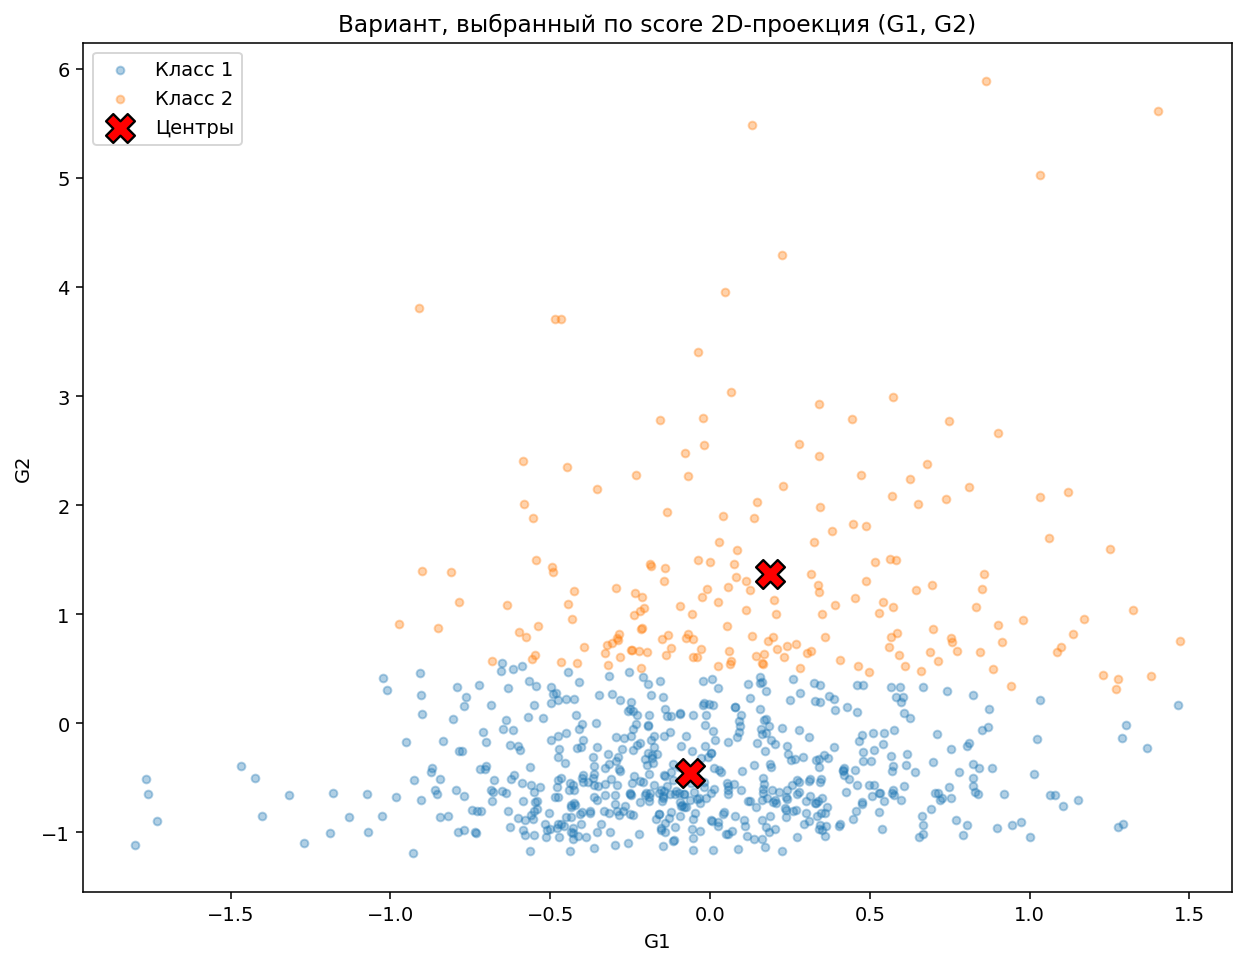

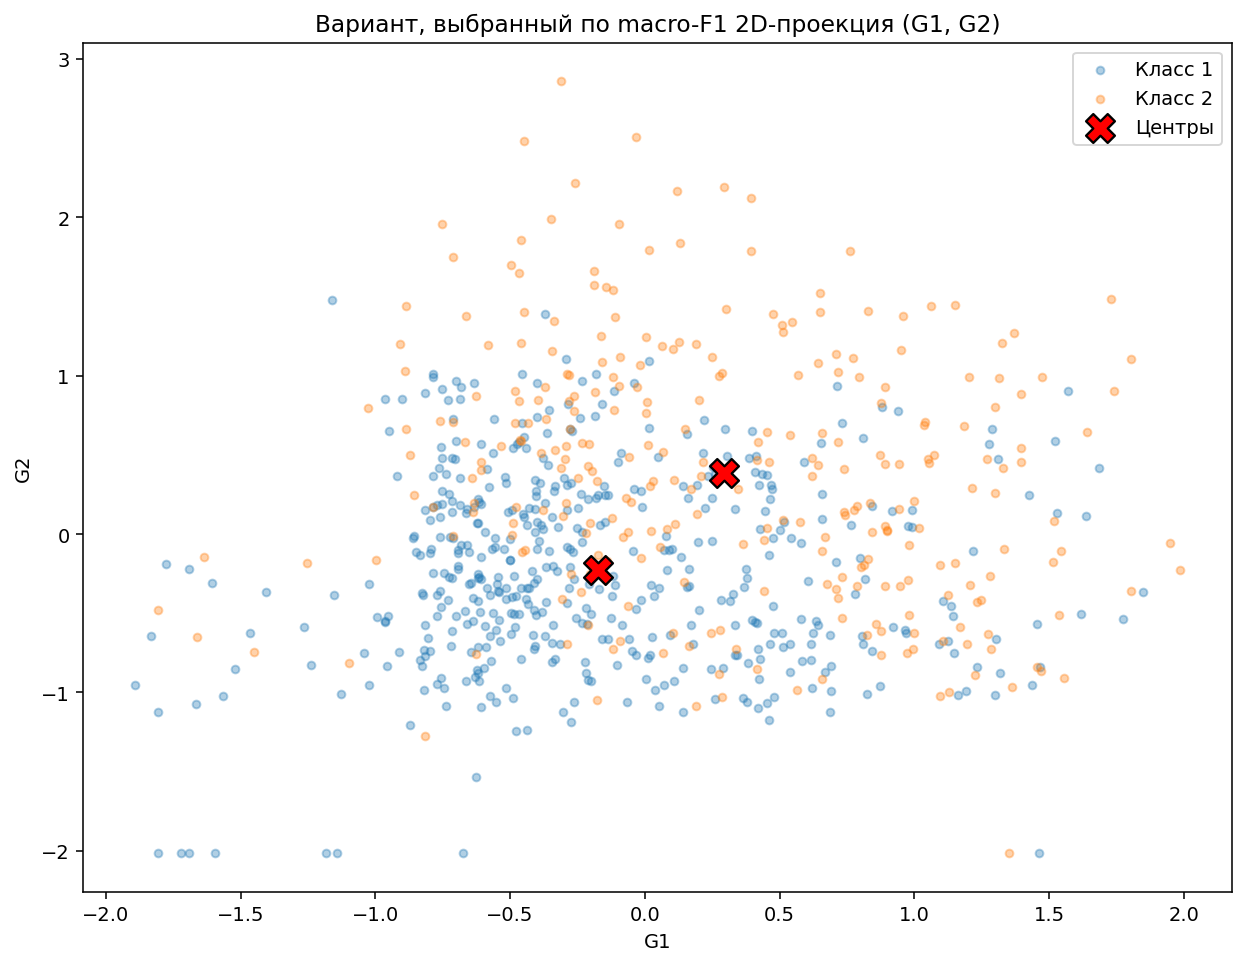

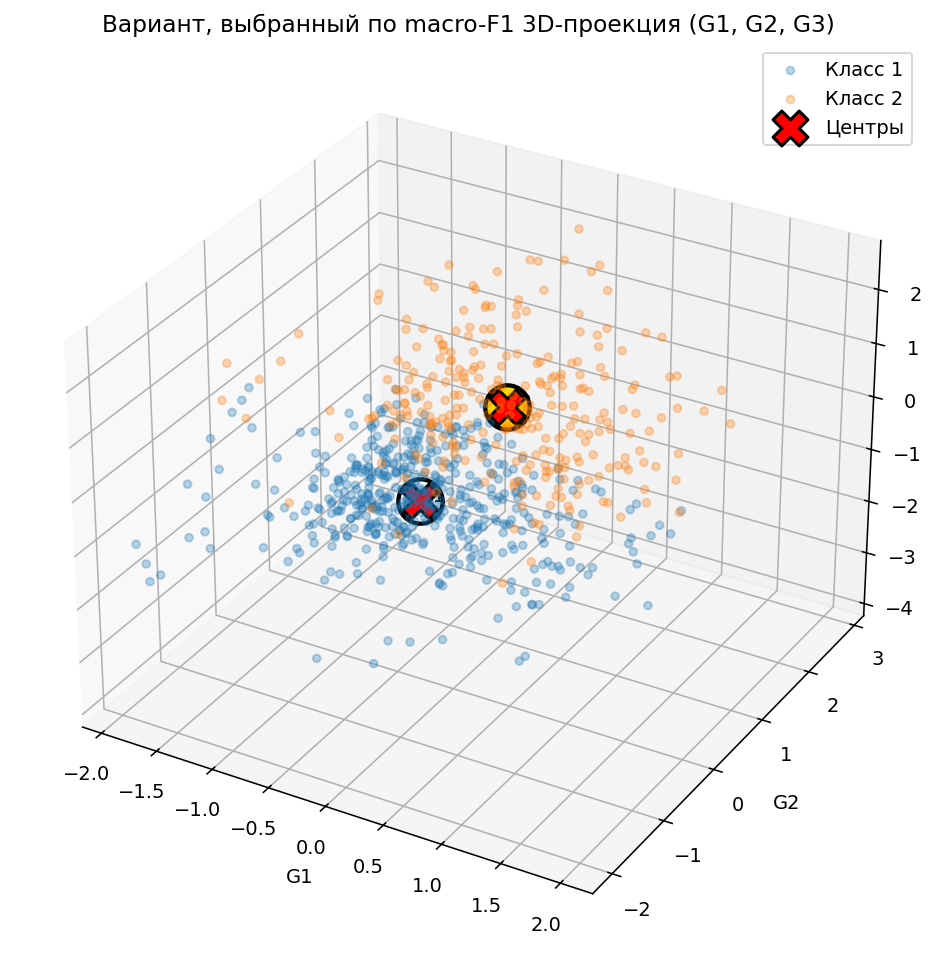

Saved extra figures:
- images/kmeans_best_score_2d.png
- images/kmeans_best_score_3d.png
- images/kmeans_best_macro_f1_2d.png
- images/kmeans_best_macro_f1_3d.png


Saved extra figures:
- images/kmeans_best_score_2d.png
- images/kmeans_best_score_3d.png
- images/kmeans_best_macro_f1_2d.png
- images/kmeans_best_macro_f1_3d.png


In [6]:
def build_groups(sim: pd.DataFrame, thr: float) -> list[list[str]]:
    cols = list(sim.index)
    adj = {c: set() for c in cols}
    for i in cols:
        for j in cols:
            if i == j:
                continue
            if max(float(sim.loc[i, j]), float(sim.loc[j, i])) >= thr:
                adj[i].add(j)
                adj[j].add(i)

    visited = set()
    comps = []
    for v in cols:
        if v in visited:
            continue
        stack = [v]
        comp = []
        visited.add(v)
        while stack:
            cur = stack.pop()
            comp.append(cur)
            for nb in adj[cur]:
                if nb not in visited:
                    visited.add(nb)
                    stack.append(nb)
        comps.append(sorted(comp))

    return sorted(comps, key=len, reverse=True)


def make_composites(components: list[list[str]]) -> tuple[np.ndarray, list[str]]:
    X = df[features].to_numpy(dtype=float)
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    Z = (X - mu) / sigma

    comp_names = []
    Z_comp = []
    for gi, comp in enumerate(components, start=1):
        idxs = [features.index(c) for c in comp]
        Z_comp.append(Z[:, idxs].mean(axis=1))
        comp_names.append(f"G{gi}")

    Z_red = np.vstack(Z_comp).T
    return Z_red, comp_names


def kmeans2_manual(Xr: np.ndarray, max_iter: int = 100, tol: float = 1e-6):
    c1 = Xr[0].copy()
    d2 = np.sum((Xr - c1) ** 2, axis=1)
    c2 = Xr[np.argmax(d2)].copy()
    centers = np.vstack([c1, c2])

    for _ in range(max_iter):
        dist1 = np.sqrt(np.sum((Xr - centers[0]) ** 2, axis=1))
        dist2 = np.sqrt(np.sum((Xr - centers[1]) ** 2, axis=1))
        labels = (dist2 < dist1).astype(int)

        new_centers = centers.copy()
        for k in [0, 1]:
            pts = Xr[labels == k]
            if len(pts) > 0:
                new_centers[k] = pts.mean(axis=0)

        if np.max(np.abs(new_centers - centers)) < tol:
            centers = new_centers
            break
        centers = new_centers

    return labels, centers


def pairwise_dist(X: np.ndarray) -> np.ndarray:
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))


def silhouette_score(X: np.ndarray, labels: np.ndarray) -> float:
    D = pairwise_dist(X)
    n = len(labels)
    s = np.zeros(n)
    for i in range(n):
        same = labels == labels[i]
        other = ~same
        if same.sum() > 1:
            a = D[i, same].sum() / (same.sum() - 1)
        else:
            a = 0.0
        b = D[i, other].mean() if other.sum() > 0 else 0.0
        denom = max(a, b)
        s[i] = (b - a) / denom if denom > 0 else 0.0
    return float(s.mean())


def davies_bouldin(X: np.ndarray, labels: np.ndarray, centers: np.ndarray) -> float:
    db = 0.0
    for k in [0, 1]:
        pts_k = X[labels == k]
        if len(pts_k) == 0:
            return float('inf')
        S_k = np.mean(np.sqrt(np.sum((pts_k - centers[k]) ** 2, axis=1)))
        worst = -1.0
        for l in [0, 1]:
            if l == k:
                continue
            pts_l = X[labels == l]
            if len(pts_l) == 0:
                return float('inf')
            S_l = np.mean(np.sqrt(np.sum((pts_l - centers[l]) ** 2, axis=1)))
            M = np.sqrt(np.sum((centers[k] - centers[l]) ** 2))
            R = (S_k + S_l) / M if M > 0 else float('inf')
            worst = max(worst, R)
        db += worst
    return float(db / 2)


def calinski_harabasz(X: np.ndarray, labels: np.ndarray, centers: np.ndarray) -> float:
    n = len(labels)
    overall = X.mean(axis=0)
    W = 0.0
    for k in [0, 1]:
        pts = X[labels == k]
        W += np.sum((pts - centers[k]) ** 2)
    B = 0.0
    for k in [0, 1]:
        nk = (labels == k).sum()
        B += nk * np.sum((centers[k] - overall) ** 2)
    if W == 0 or n <= 2:
        return 0.0
    return float((B / 1) / (W / (n - 2)))


SIMS = {
    'K': K,
    'abs_phi': PHI.abs(),
    'abs_Q': Q.abs(),
    'abs_Y': Y.abs(),
}

def threshold_candidates(sim: pd.DataFrame) -> list[float]:
    X = sim.to_numpy(dtype=float)
    n = X.shape[0]
    off = X[~np.eye(n, dtype=bool)]
    off = off[np.isfinite(off)]
    if len(off) == 0:
        return [0.0]

    vals = np.unique(np.round(off, 12))
    vals.sort()

    eps = 1e-9
    # thr > max(off)  => нет рёбер => m = p
    # thr <= min(off) => максимум рёбер => m минимально
    cands = [float(vals[-1] + eps)] + [float(v) for v in vals.tolist()] + [float(vals[0] - eps)]

    # Уберём дубли из-за eps/округления
    out = []
    for v in cands:
        if not out or abs(v - out[-1]) > 1e-12:
            out.append(v)
    return out


thresholds = {name: threshold_candidates(sim) for name, sim in SIMS.items()}

rows = []
for name, sim in SIMS.items():
    for thr in thresholds[name]:
        comps = build_groups(sim, float(thr))
        Z_red, comp_names = make_composites(comps)
        m = Z_red.shape[1]
        if m < 2:
            continue

        labels_tmp, centers_tmp = kmeans2_manual(Z_red)
        n1 = int((labels_tmp == 0).sum())
        n2 = int((labels_tmp == 1).sum())
        balance = min(n1, n2) / max(n1, n2)

        sil = silhouette_score(Z_red, labels_tmp)
        db = davies_bouldin(Z_red, labels_tmp, centers_tmp)
        ch = calinski_harabasz(Z_red, labels_tmp, centers_tmp)

        # Итоговый критерий (обоснование: хотим sil↑, ch↑, db↓, m↓, баланс↑)
        score = sil - 0.15 * np.log1p(db) + 0.02 * np.log1p(ch) - 0.03 * m + 0.10 * balance

        y = df['Outcome'].to_numpy(dtype=int)

        def external_metrics_from_pred(pred: np.ndarray) -> dict[str, float]:
            tn = int(((pred == 0) & (y == 0)).sum())
            fp = int(((pred == 1) & (y == 0)).sum())
            fn = int(((pred == 0) & (y == 1)).sum())
            tp = int(((pred == 1) & (y == 1)).sum())
            n = len(y)

            acc = (tp + tn) / n if n else 0.0

            prec1 = tp / (tp + fp) if (tp + fp) else 0.0
            rec1 = tp / (tp + fn) if (tp + fn) else 0.0
            f11 = (2 * prec1 * rec1 / (prec1 + rec1)) if (prec1 + rec1) else 0.0

            prec0 = tn / (tn + fn) if (tn + fn) else 0.0
            rec0 = tn / (tn + fp) if (tn + fp) else 0.0
            f10 = (2 * prec0 * rec0 / (prec0 + rec0)) if (prec0 + rec0) else 0.0

            f1_macro = 0.5 * (f10 + f11)
            bal_acc = 0.5 * (rec0 + rec1)

            return {
                'accuracy': float(acc),
                'precision_1': float(prec1),
                'recall_1': float(rec1),
                'f1_1': float(f11),
                'f1_macro': float(f1_macro),
                'balanced_accuracy': float(bal_acc),
            }

        m0 = external_metrics_from_pred(labels_tmp.astype(int))
        m1 = external_metrics_from_pred((1 - labels_tmp).astype(int))
        ext = m0 if (m0['f1_macro'] >= m1['f1_macro']) else m1

        rows.append({
            **ext,
            'measure': name,
            'thr': float(thr),
            'm': int(m),
            'balance': float(balance),
            'silhouette': float(sil),
            'davies_bouldin': float(db),
            'calinski_harabasz': float(ch),
            'score': float(score),
            'components': comps,
            'comp_names': comp_names,
        })

results = pd.DataFrame(rows).sort_values(['score'], ascending=False).reset_index(drop=True)
print('Лучшие варианты (top-10) по score:')
display(results[['measure','thr','m','balance','silhouette','davies_bouldin','calinski_harabasz','score','f1_macro','balanced_accuracy']].head(10))

best_by_score = results.iloc[0]
best_by_macro_f1 = results.sort_values('f1_macro', ascending=False).reset_index(drop=True).iloc[0]

print('\nЛучший по score:')
print(best_by_score[['measure','thr','m','silhouette','davies_bouldin','calinski_harabasz','balance','score','accuracy','f1_macro','balanced_accuracy']].to_string())

print('\nЛучший по macro-F1:')
print(best_by_macro_f1[['measure','thr','m','silhouette','davies_bouldin','calinski_harabasz','balance','score','accuracy','f1_macro','balanced_accuracy']].to_string())

best = best_by_macro_f1

measures_order = ['abs_Y', 'abs_Q', 'abs_phi', 'K']
ms = list(range(2, 9))

def mst_groups(sim: pd.DataFrame, target_m: int) -> tuple[list[list[str]], float]:
    cols = list(sim.index)
    p = len(cols)
    if target_m < 1 or target_m > p:
        raise ValueError('target_m out of range')

    edges = []
    for i in range(p):
        for j in range(i + 1, p):
            w = max(float(sim.iloc[i, j]), float(sim.iloc[j, i]))
            edges.append((w, i, j))
    edges.sort(reverse=True, key=lambda t: t[0])

    parent = list(range(p))
    size = [1] * p

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> bool:
        ra, rb = find(a), find(b)
        if ra == rb:
            return False
        if size[ra] < size[rb]:
            ra, rb = rb, ra
        parent[rb] = ra
        size[ra] += size[rb]
        return True

    comps = p
    last_w = float('nan')
    for w, i, j in edges:
        if comps <= target_m:
            break
        if union(i, j):
            comps -= 1
            last_w = w

    groups = {}
    for i, name in enumerate(cols):
        r = find(i)
        groups.setdefault(r, []).append(name)

    components = [sorted(v) for v in groups.values()]
    components = sorted(components, key=len, reverse=True)
    return components, last_w


rows28 = []
for meas in measures_order:
    for mm in ms:
        sub = results[(results['measure'] == meas) & (results['m'] == mm)].copy()
        if len(sub) == 0:
            sim = SIMS[meas]
            comps, thr_mst = mst_groups(sim, int(mm))
            Xr, _ = make_composites(comps)
            lab, cen = kmeans2_manual(Xr)

            n1 = int((lab == 0).sum())
            n2 = int((lab == 1).sum())
            balance = min(n1, n2) / max(n1, n2)

            sil = silhouette_score(Xr, lab)
            db = davies_bouldin(Xr, lab, cen)
            ch = calinski_harabasz(Xr, lab, cen)
            score = sil - 0.15 * np.log1p(db) + 0.02 * np.log1p(ch) - 0.03 * int(mm) + 0.10 * balance

            y = df['Outcome'].to_numpy(dtype=int)
            m0 = external_metrics_from_pred(lab.astype(int))
            m1 = external_metrics_from_pred((1 - lab).astype(int))
            ext = m0 if (m0['f1_macro'] >= m1['f1_macro']) else m1

            rows28.append({
                'measure': meas,
                'thr': float(thr_mst),
                'm': int(mm),
                'balance': float(balance),
                'silhouette': float(sil),
                'davies_bouldin': float(db),
                'calinski_harabasz': float(ch),
                'score': float(score),
                **ext,
            })
        else:
            best_row = sub.sort_values(['f1_macro', 'balanced_accuracy', 'score'], ascending=False).iloc[0]
            rows28.append(best_row.to_dict())

best_by_measure_m_export = pd.DataFrame(rows28)[[
    'measure','thr','m','balance','silhouette','davies_bouldin','calinski_harabasz','score',
    'accuracy','balanced_accuracy','f1_macro','precision_1','recall_1','f1_1'
]].copy()

best_by_measure_m_export['measure'] = best_by_measure_m_export['measure'].astype(str).str.replace('_', r'\_', regex=False)

best_by_measure_m_export = best_by_measure_m_export.fillna('--')

best_by_measure_m_export = best_by_measure_m_export.rename(
    columns={
        'thr': 'thr',
        'm': 'm',
        'balance': 'balance',
        'silhouette': 'silhouette',
        'davies_bouldin': 'Davies--Bouldin',
        'calinski_harabasz': 'Calinski--Harabasz',
        'score': 'score',
        'accuracy': 'Acc',
        'balanced_accuracy': 'BalAcc',
        'f1_macro': 'F1-macro',
        'precision_1': 'Prec(1)',
        'recall_1': 'Rec(1)',
        'f1_1': 'F1(1)',
    }
)

best_by_measure_m_export.to_latex(
    'tables/threshold_search.tex',
    index=False,
    escape=False,
)
print('Saved (28 rows): tables/threshold_search.tex')
BEST_MEASURE = str(best['measure'])
BEST_THR = float(best['thr'])
components = best['components']
comp_names = best['comp_names']
Z_red, _ = make_composites(components)

print('\nВыбрано для итогового результата (по максимуму macro-F1):')
print('  measure =', BEST_MEASURE)
print('  thr =', BEST_THR)
print('  m =', int(best['m']))
print('  silhouette =', float(best['silhouette']))
print('  davies_bouldin =', float(best['davies_bouldin']))
print('  calinski_harabasz =', float(best['calinski_harabasz']))
print('  balance =', float(best['balance']))
print('  accuracy =', float(best['accuracy']))
print('  groups:')
for gi, comp in enumerate(components, start=1):
    print(f'    G{gi}: {comp}')

quality_table = results[['measure','thr','m','balance','silhouette','davies_bouldin','calinski_harabasz','score','accuracy','balanced_accuracy','f1_macro','precision_1','recall_1','f1_1']].copy()
quality_table.to_csv('tables/threshold_search.csv', index=False)

quality_table_export = quality_table.copy()
quality_table_export['measure'] = quality_table_export['measure'].astype(str).str.replace('_', r'\_', regex=False)
quality_table_export = quality_table_export.rename(
    columns={
        'thr': 'thr',
        'm': 'm',
        'balance': 'balance',
        'silhouette': 'silhouette',
        'davies_bouldin': 'Davies--Bouldin',
        'calinski_harabasz': 'Calinski--Harabasz',
        'score': 'score',
        'accuracy': 'Acc',
        'balanced_accuracy': 'BalAcc',
        'f1_macro': 'F1-macro',
        'precision_1': 'Prec(1)',
        'recall_1': 'Rec(1)',
        'f1_1': 'F1(1)',
    }
)
quality_table_export.to_latex(
    'tables/threshold_search_full.tex',
    index=False,
    escape=False,
    float_format=lambda x: f"{x:.4f}",
)

acc_by_m = (
    results.groupby('m', as_index=False)
    .agg(
        best_accuracy=('accuracy', 'max'),
        best_balanced_accuracy=('balanced_accuracy', 'max'),
        best_f1_macro=('f1_macro', 'max'),
        best_score=('score', 'max'),
    )
    .sort_values('m')
)
acc_by_m.to_csv('tables/accuracy_by_m.csv', index=False)
acc_by_m.to_latex(
    'tables/accuracy_by_m.tex',
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.4f}",
)

print('Saved: tables/threshold_search.csv and tables/threshold_search.tex')
print('Saved: tables/accuracy_by_m.csv and tables/accuracy_by_m.tex')

def plot_and_save(X: np.ndarray, labels: np.ndarray, centers: np.ndarray, fname2d: str, fname3d: str | None = None, title_prefix: str = '') -> None:
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111)
    m1 = labels == 0
    m2 = labels == 1
    ax.scatter(X[m1, 0], X[m1, 1], s=16, alpha=0.35, label='Класс 1')
    ax.scatter(X[m2, 0], X[m2, 1], s=16, alpha=0.35, label='Класс 2')
    ax.scatter(centers[:, 0], centers[:, 1], s=220, c='red', marker='X', edgecolors='black', linewidths=1.2, label='Центры')
    ax.set_xlabel('G1')
    ax.set_ylabel('G2')
    ax.set_title(f'{title_prefix} 2D-проекция (G1, G2)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fname2d, bbox_inches='tight')
    plt.show()

    if fname3d is not None and X.shape[1] >= 3:
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')

        ax.scatter(X[m1, 0], X[m1, 1], X[m1, 2], s=16, alpha=0.30, label='Класс 1')
        ax.scatter(X[m2, 0], X[m2, 1], X[m2, 2], s=16, alpha=0.30, label='Класс 2')

        face = ['white', 'gold']
        for k in range(centers.shape[0]):
            ax.scatter(
                [centers[k, 0]], [centers[k, 1]], [centers[k, 2]],
                s=520,
                c=face[k % len(face)],
                marker='o',
                edgecolors='black',
                linewidths=2.2,
                depthshade=False,
                label=None,
            )
            ax.scatter(
                [centers[k, 0]], [centers[k, 1]], [centers[k, 2]],
                s=320,
                c='red',
                marker='X',
                edgecolors='black',
                linewidths=1.6,
                depthshade=False,
                label='Центры' if k == 0 else None,
            )
            ax.text(
                centers[k, 0], centers[k, 1], centers[k, 2],
                f'C{k+1}',
                fontsize=10,
                color='black',
            )

        ax.set_xlabel('G1')
        ax.set_ylabel('G2')
        ax.set_zlabel('G3')
        ax.set_title(f'{title_prefix} 3D-проекция (G1, G2, G3)')
        ax.legend()
        plt.tight_layout()
        plt.savefig(fname3d, bbox_inches='tight')
        plt.show()


def run_variant(best_row: pd.Series, tag: str, title: str) -> None:
    comps = best_row['components']
    Xr, _ = make_composites(comps)
    lab, cen = kmeans2_manual(Xr)
    plot_and_save(
        Xr, lab, cen,
        fname2d=f'images/kmeans_{tag}_2d.png',
        fname3d=f'images/kmeans_{tag}_3d.png',
        title_prefix=title,
    )

run_variant(best_by_score, 'best_score', 'Вариант, выбранный по score')
run_variant(best_by_macro_f1, 'best_macro_f1', 'Вариант, выбранный по macro-F1')

print('Saved extra figures:')
print('- images/kmeans_best_score_2d.png')
print('- images/kmeans_best_score_3d.png')
print('- images/kmeans_best_macro_f1_2d.png')
print('- images/kmeans_best_macro_f1_3d.png')

In [7]:
Xr = Z_red

c1 = Xr[0].copy()
d2 = np.sum((Xr - c1) ** 2, axis=1)
c2 = Xr[np.argmax(d2)].copy()
centers = np.vstack([c1, c2])

max_iter = 100
tol = 1e-6

for _ in range(max_iter):
    dist1 = np.sqrt(np.sum((Xr - centers[0]) ** 2, axis=1))
    dist2 = np.sqrt(np.sum((Xr - centers[1]) ** 2, axis=1))
    labels = (dist2 < dist1).astype(int)  # 0/1

    new_centers = centers.copy()
    for k in [0, 1]:
        pts = Xr[labels == k]
        if len(pts) > 0:
            new_centers[k] = pts.mean(axis=0)

    if np.max(np.abs(new_centers - centers)) < tol:
        centers = new_centers
        break
    centers = new_centers

# Результат
out = df.copy()
out['Cluster'] = labels + 1

counts = out['Cluster'].value_counts().sort_index()
print('Размеры кластеров:')
display(counts)

centers_df = pd.DataFrame(centers, columns=comp_names, index=[1, 2])
centers_df.index.name = 'Cluster'
print('Центры в композитных координатах (G1..Gm):')
display(centers_df.round(4))

Размеры кластеров:


Cluster
1    482
2    286
Name: count, dtype: int64

Центры в композитных координатах (G1..Gm):


,G1,G2,G3,G4
Cluster,,,,
1,-0.1753,-0.2297,-0.5629,-0.2712
2,0.2955,0.3871,0.9487,0.4571


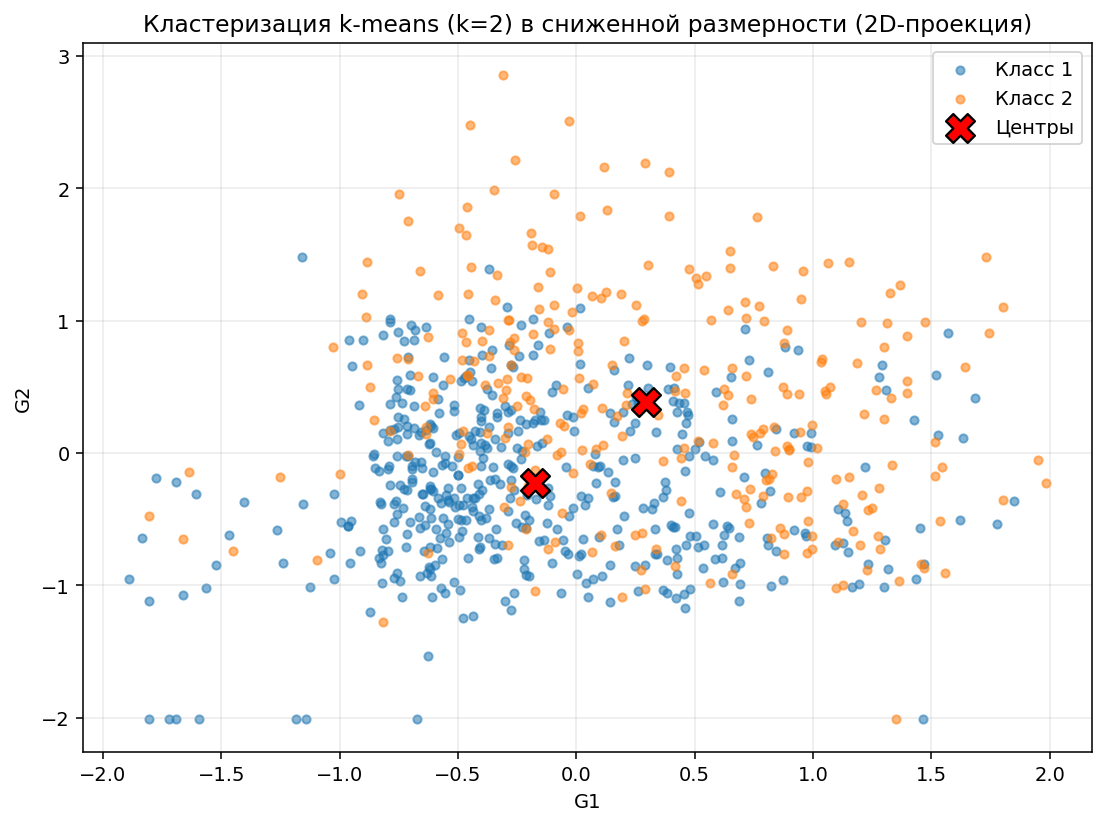

In [8]:
# Визуализация кластеров в 2D по двум первым композитным координатам (G1 и G2)

if Z_red.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    mask1 = labels == 0
    mask2 = labels == 1

    plt.scatter(Z_red[mask1, 0], Z_red[mask1, 1], s=18, alpha=0.55, label='Класс 1')
    plt.scatter(Z_red[mask2, 0], Z_red[mask2, 1], s=18, alpha=0.55, label='Класс 2')

    plt.scatter(centers[:, 0], centers[:, 1], s=220, c='red', marker='X', edgecolors='black', linewidths=1.2, label='Центры')

    plt.xlabel('G1')
    plt.ylabel('G2')
    plt.title('Кластеризация k-means (k=2) в сниженной размерности (2D-проекция)')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig('images/kmeans_reduced_2d.png', bbox_inches='tight')
    plt.show()
else:
    print('Недостаточно композитных признаков для 2D-визуализации (m < 2).')

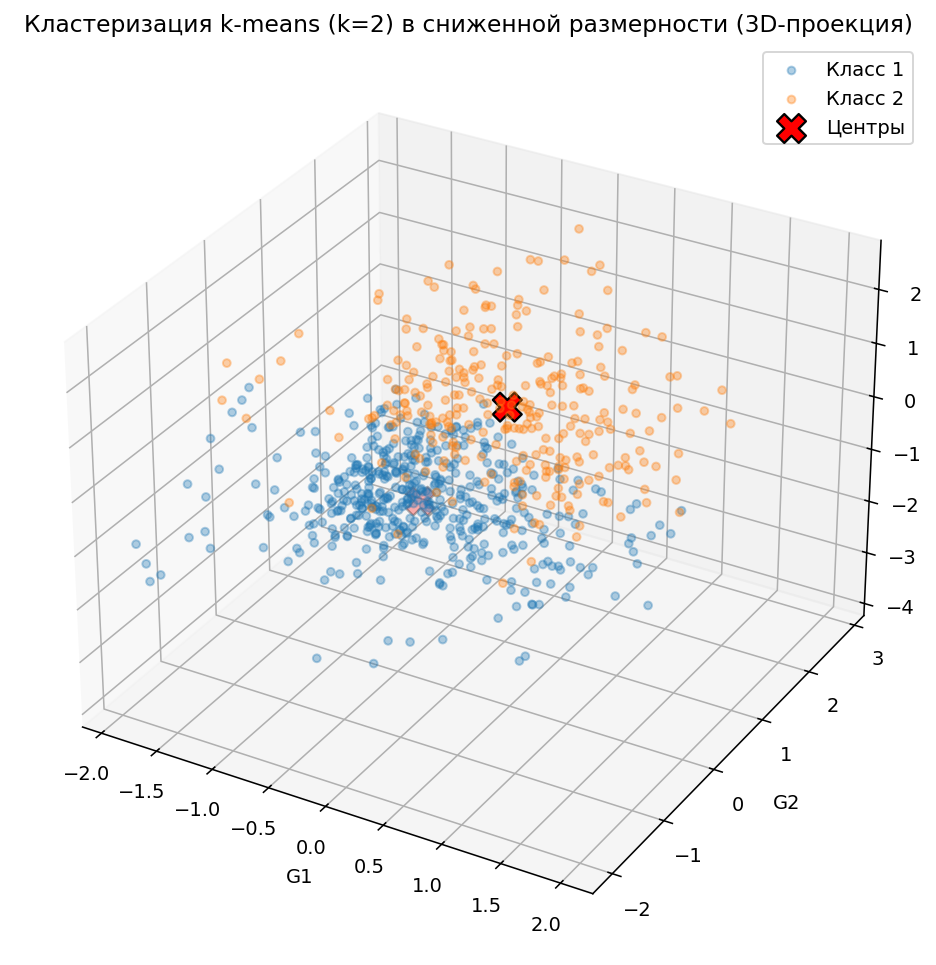

In [9]:
# 3D-проекция кластеризации по (G1, G2, G3)

if Z_red.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    mask1 = labels == 0
    mask2 = labels == 1

    ax.scatter(Z_red[mask1, 0], Z_red[mask1, 1], Z_red[mask1, 2], s=16, alpha=0.35, label='Класс 1')
    ax.scatter(Z_red[mask2, 0], Z_red[mask2, 1], Z_red[mask2, 2], s=16, alpha=0.35, label='Класс 2')

    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=220, c='red', marker='X', edgecolors='black', linewidths=1.2, label='Центры')

    ax.set_xlabel('G1')
    ax.set_ylabel('G2')
    ax.set_zlabel('G3')
    ax.set_title('Кластеризация k-means (k=2) в сниженной размерности (3D-проекция)')
    ax.legend()

    plt.tight_layout()
    plt.savefig('images/kmeans_reduced_3d.png', bbox_inches='tight')
    plt.show()
else:
    print('Недостаточно композитных признаков для 3D-визуализации (m < 3).')

In [10]:
# Интерпретация через уровни исходных признаков
# Сравним средние/медианные значения всех исходных признаков в каждом классе.

summary = out.groupby('Cluster')[features].agg(['mean', 'median', 'std'])
print('Статистики по исходным показателям в классах:')
display(summary)

overall = df[features].agg(['mean', 'median', 'std'])
print('Общие уровни по всей выборке:')
display(overall)

# Внешняя проверка (НЕ интерпретация смысла): сравнение с Outcome
print('Внешняя проверка: распределение Outcome по классам (для сравнения):')
outcome_tab = pd.crosstab(out['Cluster'], out['Outcome'], rownames=['Cluster'], colnames=['Outcome'])
display(outcome_tab)

# Внешние контрольные метрики по Outcome (лучшее сопоставление меток)
if outcome_tab.shape == (2, 2):
    # outcome_tab: rows=Cluster(1,2), cols=Outcome(0,1)
    a = int(outcome_tab.iloc[0, 0])
    b = int(outcome_tab.iloc[0, 1])
    c = int(outcome_tab.iloc[1, 0])
    d = int(outcome_tab.iloc[1, 1])
    n_total = a + b + c + d

    # Вариант соответствия: Cluster1->0, Cluster2->1
    tn0, fn0, fp0, tp0 = a, b, c, d
    acc0 = (tp0 + tn0) / n_total if n_total else 0.0

    prec1_0 = tp0 / (tp0 + fp0) if (tp0 + fp0) else 0.0
    rec1_0 = tp0 / (tp0 + fn0) if (tp0 + fn0) else 0.0
    f1_1_0 = (2 * prec1_0 * rec1_0 / (prec1_0 + rec1_0)) if (prec1_0 + rec1_0) else 0.0

    prec0_0 = tn0 / (tn0 + fn0) if (tn0 + fn0) else 0.0
    rec0_0 = tn0 / (tn0 + fp0) if (tn0 + fp0) else 0.0
    f1_0_0 = (2 * prec0_0 * rec0_0 / (prec0_0 + rec0_0)) if (prec0_0 + rec0_0) else 0.0

    f1_macro_0 = 0.5 * (f1_0_0 + f1_1_0)
    balacc_0 = 0.5 * (rec0_0 + rec1_0)

    # Переворот соответствия: Cluster1->1, Cluster2->0
    tn1, fn1, fp1, tp1 = c, d, a, b
    acc1 = (tp1 + tn1) / n_total if n_total else 0.0

    prec1_1 = tp1 / (tp1 + fp1) if (tp1 + fp1) else 0.0
    rec1_1 = tp1 / (tp1 + fn1) if (tp1 + fn1) else 0.0
    f1_1_1 = (2 * prec1_1 * rec1_1 / (prec1_1 + rec1_1)) if (prec1_1 + rec1_1) else 0.0

    prec0_1 = tn1 / (tn1 + fn1) if (tn1 + fn1) else 0.0
    rec0_1 = tn1 / (tn1 + fp1) if (tn1 + fp1) else 0.0
    f1_0_1 = (2 * prec0_1 * rec0_1 / (prec0_1 + rec0_1)) if (prec0_1 + rec0_1) else 0.0

    f1_macro_1 = 0.5 * (f1_0_1 + f1_1_1)
    balacc_1 = 0.5 * (rec0_1 + rec1_1)

    # Выбираем соответствие по максимуму macro-F1
    if f1_macro_1 > f1_macro_0:
        acc, balacc, f1_macro = acc1, balacc_1, f1_macro_1
        prec1, rec1, f1_1 = prec1_1, rec1_1, f1_1_1
    else:
        acc, balacc, f1_macro = acc0, balacc_0, f1_macro_0
        prec1, rec1, f1_1 = prec1_0, rec1_0, f1_1_0
else:
    acc = balacc = f1_macro = prec1 = rec1 = f1_1 = 0.0

print(f"Acc = {acc:.6f}")
print(f"BalAcc = {balacc:.6f}")
print(f"F1-macro = {f1_macro:.6f}")
print(f"Prec(1) = {prec1:.6f}")
print(f"Rec(1) = {rec1:.6f}")
print(f"F1(1) = {f1_1:.6f}")

# Экспорт внешних метрик для отчёта
with open('tables/accuracy.txt', 'w', encoding='utf-8') as f:
    f.write(f"Acc={acc:.6f}\nBalAcc={balacc:.6f}\nF1-macro={f1_macro:.6f}\n")

with open('tables/accuracy.tex', 'w', encoding='utf-8') as f:
    f.write('\\begin{tabular}{lr}\n')
    f.write('\\toprule\n')
    f.write('Метрика & Значение \\\\\n')
    f.write('\\midrule\n')
    f.write(f'Acc & {acc:.6f} \\\\\n')
    f.write(f'BalAcc & {balacc:.6f} \\\\\n')
    f.write(f'F1-macro & {f1_macro:.6f} \\\\\n')
    f.write(f'Prec(1) & {prec1:.6f} \\\\\n')
    f.write(f'Rec(1) & {rec1:.6f} \\\\\n')
    f.write(f'F1(1) & {f1_1:.6f} \\\\\n')
    f.write('\\bottomrule\n')
    f.write('\\end{tabular}\n')

out.to_csv('diabetes_kmeans_clusters_reduced.csv', index=False)
print('Saved: diabetes_kmeans_clusters_reduced.csv')

Статистики по исходным показателям в классах:


Pregnancies                      Glucose                    \
               mean median       std        mean median        std   
Cluster                                                              
1          3.348548    2.0  3.053727  102.908714  104.0  20.403924   
2          4.681818    4.0  3.701136  151.206294  148.0  24.069696   

        BloodPressure                   SkinThickness  ...     Insulin  \
                 mean median        std          mean  ...         std   
Cluster                                                ...               
1           66.068465   69.0  19.690471     17.796680  ...   66.526068   
2           74.223776   76.0  17.664086     25.153846  ...  153.060962   

               BMI                  DiabetesPedigreeFunction                   \
              mean median       std                     mean median       std   
Cluster                                                                         
1        30.151660   30.1  7.422568                 0.382068  0.304  0.229388   
2        35.095105   34.4  7.675391                 0.623231  0.550  0.412316   

               Age                    
              mean median        std  
Cluster                               
1        30.636929   27.0  10.472165  
2        37.629371   36.0  12.503012  

[2 rows x 24 columns]

Общие уровни по всей выборке:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
median,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232


Внешняя проверка: распределение Outcome по классам (для сравнения):


Outcome,0,1
Cluster,,
1,394,88
2,106,180


Acc = 0.747396
BalAcc = 0.729821
F1-macro = 0.726132
Prec(1) = 0.629371
Rec(1) = 0.671642
F1(1) = 0.649819
Saved: diabetes_kmeans_clusters_reduced.csv


In [11]:
# 1) Группы признаков после сокращения размерности
comp_table = pd.DataFrame({"Group": comp_names, "Features": [", ".join(c) for c in components]})
comp_latex = comp_table.to_latex(index=False, escape=True)
with open('tables/reduction_groups.tex', 'w', encoding='utf-8') as f:
    f.write(comp_latex)

# 2) Размеры кластеров
cluster_sizes = counts.rename('Count').reset_index().rename(columns={'index': 'Cluster'})
cluster_sizes_latex = cluster_sizes.to_latex(index=False, escape=True)
with open('tables/cluster_sizes.tex', 'w', encoding='utf-8') as f:
    f.write(cluster_sizes_latex)

# 3) Центры кластеров (в композитных координатах)
centers_export = centers_df.copy() if 'centers_df' in globals() else pd.DataFrame(centers, columns=comp_names, index=[1, 2])
centers_export.index.name = 'Cluster'
centers_latex = centers_export.to_latex(escape=True, float_format=lambda x: f"{x:.4f}")
with open('tables/cluster_centers.tex', 'w', encoding='utf-8') as f:
    f.write(centers_latex)

# 4) Внешняя проверка (Outcome vs Cluster) — только как контроль
outcome_tab = pd.crosstab(out['Cluster'], out['Outcome'], rownames=['Cluster'], colnames=['Outcome'])
outcome_latex = outcome_tab.to_latex(index=True)
with open('tables/outcome_vs_cluster.tex', 'w', encoding='utf-8') as f:
    f.write(outcome_latex)

print('Saved LaTeX tables:')
print('- tables/reduction_groups.tex')
print('- tables/cluster_sizes.tex')
print('- tables/cluster_centers.tex')
print('- tables/outcome_vs_cluster.tex')
print('- tables/threshold_search.tex')
print('- tables/accuracy_by_m.tex')
print('Saved figures:')
print('- images/colligation_K_heatmap.png')
print('- images/phi_heatmap.png')
print('- images/yule_Q_heatmap.png')
print('- images/yule_Y_heatmap.png')
print('- images/kmeans_reduced_2d.png')
print('- images/kmeans_reduced_3d.png')


Saved LaTeX tables:
- tables/reduction_groups.tex
- tables/cluster_sizes.tex
- tables/cluster_centers.tex
- tables/outcome_vs_cluster.tex
- tables/threshold_search.tex
- tables/accuracy_by_m.tex
Saved figures:
- images/colligation_K_heatmap.png
- images/phi_heatmap.png
- images/yule_Q_heatmap.png
- images/yule_Y_heatmap.png
- images/kmeans_reduced_2d.png
- images/kmeans_reduced_3d.png
